# 2. Method 1: Spectrum Binning, Feature Hashing and OMS

## Goals:

In this notebook, we'll be exploring the following three core concepts:

1. [What Open Modification Search (OMS) is, and why it can be computationally expensive.](#21-open-modification-search-(OMS))

2. [How nearest neighbor algorithms work, and how they can be applied to OMS.](#22-clustering)

3. [Why raw mass spectra aren't compatible with clustering algorithms,](#why-vectorize-spectra) [and how spectral hashing enables spectra to be clustered.](#241-step-2-feature-hashing)

In [1]:
# @title Run this cell to import all necessary packages

#%pip install matplotlib

import spectrum_utils.plot as sup
from pyteomics import mzml
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rapidhash import rapidhash
from IPython.display import display, Latex
from util import *

import importlib
import SpectrumWithTransformations as swt_module
import SpectrumWithTransformations
from spectrum_utils.proforma import Modification
from util import prove_similarity_preservation_plots_and_statistics

importlib.reload(swt_module)

<module 'SpectrumWithTransformations' from '/Users/aleeza/Visual_Studio/MS_spectra_encoding/SpectrumWithTransformations.py'>

## 2.1 Open Modification Search (OMS)

### 2.1.1 Spectral library search

For this tutorial, we'll be searching a data file where a single protein ([Carbonic Anhydrase](https://www.uniprot.org/uniprotkb/P00921/entry)) was digested with trypsin, then analyzed using LC-MS/MS. We start with a set of MS2 spectra, which we'll call *experimental spectra* (although they're also referred to as *query spectra*), and it's our job to try and identify these spectra by searching the data.

In order to identify peptides in the experimental data, we will compare the experimental spectra to *library spectra* in a spectral library. A spectral libary is a collection of spectra that are annotated with the peptides that gave rise to each spectrum. By comparing experimental spectra against library spectra, you can determine which peptides are present in your experimental data.  A full library search requires E*L comparisons, where E is the number experimental spectra and L is the number of library spectra. However, if both your spectral library and your experimental data are large, this can be a time consuming process!

In order to make the search less computationally expensive, we limit the comparisons. For each experimental MS2 spectrum, we know the mass of the peptide that was isolated and fragmented to generate the spectrum. For the library spectrum, we know the theoretical mass of the peptide that is associated with the spectrum. So, we can restric out spectrum-spectrum comparisons so that only library spectra where the peptide mass is close to the experimental spectrum's precursor mass are considered for comparison. This makes the search less computationally expensive, and therefore much faster!

Below is one real peptide-spectrum match from our dataset. This is the kind of identification a traditional library-style search can recover efficiently when the peptide is unmodified.

In [2]:
demo_mzml_path = '04-17-23_CA_Tryp_HCD_10min-calib.mzML'
matched_scan = 3220
matched_peptide = 'SHHWGYGK'


# Note that the `get_MS2_object` function is something we defined in `util.py` - it just extracts the relevant spectrum from the mzML file 
# and formats it as a `spectrum_utils` object so we can plot it nicely. It also does some filtering for MS2 spectra
# Only the peaks that are at least as intense a 5% of the most intense peak are retained.
matched_spectrum = get_MS2_object(
    mzml_path=demo_mzml_path,
    scan=matched_scan,
    peptide=matched_peptide,
)

display(plot_MS2(
    matched_spectrum,
    title=f'Matched spectrum: {matched_peptide} (scan {matched_scan})',
))

### 2.1.2 Post-translational modifications and open modification search

We performed such a search. However, after it was done, we noticed that while we identified some of the spectra, corresponding to almost every peptide that can be produced by digesting Carbonic Anhydrase, a large portion of the spectra in our data go unmatched. What is happening here?

The answer is post-translational modifications, or PTMs\*. 

When we only looked for unmodified peptides, we had a relatively constrained set of theoretical spectra. However, once we start considering PTMs, our search space explodes. Any given PTM could appear on multiple residues. A peptide could even bear two or more PTMs. While PTMs are common, and biologically important, they make search considerably more difficult.

The next spectrum is a real match from the same dataset, but now the assigned peptide carries multiple modifications. Even before we annotate the fragment peaks, it already illustrates why the search problem becomes harder: once modified peptides are allowed, the set of plausible peptide explanations grows dramatically.

One way to account for PTMs is through **Open Modification Search (OMS).**

In OMS, every peptide in the database is considered as a potential match to every MS2 fragmentation spectrum. When a peptide-spectrum match is found, you can look for *mass shifts* to identify PTMs. All possible modifications are implicitly considered. You can imagine that this is very useful for discovering unexpected or novel modifications, but it comes at a cost - it is *very* computationally expensive because we can no longer reduce the number of spectrum-spectrum comparisons by filtering based on precursor mass.

We'll use **clustering** to cut down this search space in Section 2.2, grouping similar spectra so we only need to compare each experimental spectrum to a small representative subset of the library.

In [3]:
modified_scan = 2940
modified_peptide =  '[Acetyl]-SHHWGYGK'

modified_spectrum = get_MS2_object(
    mzml_path=demo_mzml_path,
    scan=modified_scan,
    peptide=modified_peptide,
)

display(plot_MS2(
    modified_spectrum,
    title=f'Modified peptide-spectrum match (scan {modified_scan})',
))

print(f'Assigned peptide: {modified_peptide}')

Assigned peptide: [Acetyl]-SHHWGYGK


<details>
<summary><strong>Definition: Database Search and PTMs</strong> </summary>

---

#### Database Search

- *Database Search* is a way to check if a peptide from your sample already exists within a database.

  - That is, if you have a spectrum but don't know its identity, checking the relevant databases (eg. humans for human samples, e. coli for e. coli samples) allows you to use someone else's identification ("annotation", rather) of that spectrum.

    - This is done via a variety of algorithms (depends on the tool you're using) to determine how close of a match a spectrum is to the database's annotated spectrum.
    
    - Note that in traditional proteomics, we can safely consider only peptides from the database with the same mass as our fragmented spectra.

#### Post-Translational Modifications (PTMs)

- *Post Translational Modifications (PTMs)* are chemical "add-ons" to proteins after being synthesized. They allow a given protein to diversify and be useful far past the dictates of its transcription and synthesis, especially given that they are reversible. 

  - *PTMs* are also studied for their uses in cell signalling and dynamic regulation of protein function.
  
  - For a less abstract, numerical example of what PTMs are - an oxygen atom as a PTM on a peptide is called oxidation. Oxidation shifts the mass of the peptide by a certain $\text{m/z}$. So if a peak is at $\text{m/z} = 230$ with charge $z$, adding an oxygen atom (~16 Da) will shift it to approximately $230 + 16/z$.


---
</details>



## 2.2  Clustering Spectra

Instead of comparing every experimental spectrum to every possible library in our database, what if we only compared them to a subset of library spectra? If we could simplify our spectral library in such a way that we found a group of spectra that could be used to represent all other spectra in the library? Then, we only need to compare our experimental spectrum against this small subset of library spectra.

How would we go about this? The first step would be to find **clusters**, or groups of library spectra that are similar to one another. We can cluster all of our *library spectra* together based on their similarity, and then for each *experimental spectrum* we want to identify, we only need to compare it to one representative spectrum from each cluster.

To reiterate - if we know the identity of one spectrum in a group ahead of time then we have a good idea of the identity of every spectrum in that cluster. This allows us to make just a single (or a few) comparisons per cluster instead of to every peptide in every cluster.

Clustering spectra is a general idea used across many tools. We will first build the intuition in a tool-agnostic way, then connect it to the specific ANN-SoLo pipeline at the end of this section.

### 2.2.1 Clustering == Lego Sorting

To understand clustering better, imagine you're building a large Lego set with ~2,000 pieces.

*The naive approach:*
* Dump all pieces out at once
* For each instruction, search through the entire pile to find the piece you need

*The clustering approach:*
* Dump all pieces out at once
* First, sort pieces into piles by shape (2x4 studs, 1x2 studs, etc.)
* For each instruction, go directly to the relevant pile

If you grab any piece from a pile, it's representative of all pieces in that pile. This lets you quickly skip irrelevant piles. Now imagine 2,000,000 pieces! The efficiency gain becomes enormous.

> There's a balance between "too specific" (too many small piles) and "too generic" (piles with mixed pieces). The same applies to clustering spectra.

<center><img src="./lego-transformation.png" style="max-width:50vw;" alt="Lego Sorting"></center>


Note that not all pieces in a particular cluster are identical, but they're fairly close to one another! The same is true for spectra in a cluster - they may not be identical, but they're similar enough that we can make the same identification for all spectra in the cluster.

To reiterate:

| Lego | Spectra |
|:---:|:---:|
| Group similar pieces into piles | Group similar spectra into clusters |
| Identify one piece per pile | Identify one spectrum per cluster (using traditional search) |
| All pieces in pile share that identity | All spectra in cluster share that peptide identity |

### 2.2.2 Representing spectra in high-dimensional space and introducing similarity

The first step in building clusters is to determine which spectra are most similar to one another. In the case of mass spectra, it's not obvious how to do this! If a mass spectrum has a peak at 1000 m/z, and another spectrum has a peak at 1000.5 m/z, does this make them similar, or different? Should we focus more on the exact mass of the peaks, or the intensities?

We need some way of taking the complex data contained in a mass spectrum and reducing it down into a format that is easier to work with. Namely, lists of numbers, so that we can measure how similar any two spectra are.

We'll define the actual similarity metric (cosine similarity + nearest-neighbor search) shortly in Section 2.6; for now, the key idea is that clustering requires every spectrum to live in the same numeric space.

For this example, we'll try and represent mass spectra in only two dimensions. That will allow us to represent a spectrum as a point in two-dimensional space, and will enable us to build clusters. The graphic below shows what this might look like.

<table style="border: none; border-collapse: collapse;">
<tr style="border: none;">
<td style="border: none; text-align: center; vertical-align: top; padding: 10px;">
<img src="Clustering-1.jpeg" height="1000"><br>
<em>Here, we represent every spectrum in 2 dimensions. For dimension one, we sum up every peak below 500 m/z. For dimension 2, we sum up every peak above 500 m/z. This gives us a 2 dimensional representation of each spectrum. We'll start with two known library spectra that represent peptides A and B.</em>
</td>
<td style="border: none; text-align: center; vertical-align: top; padding: 10px;">
<img src="Clustering-2.jpeg" height="1000"><br>
<em>Here, we start adding more and more spectra. By transforming every new spectrum into the same two-dimensional space, it's easy to compare the incoming experimental spectra to the library spectra that represent A and B, and see which of the library spectra the experimental spectrum is more similar to.</em>
</td>
</tr>
</table>

Below, we will do exactly that with the matched spectrum, the modified spectrum, and one additional random spectrum from the same run. The point is that just because we *can* represent spectra in two dimensions, this doesn't mean that we *should*.  In the example below, we show that with this naive 2D representation the spectrum that was matched to the acetylated form of the peptide SHHWGYGK is as far away as a random spectrum. This encoding is only a toy example that makes the idea of a shared numeric space concrete.

In [4]:
DIMENSION_SPLIT = 500
RANDOM_SCAN_SEED = 7

# This function split our spectrum into two dimensions: the summed intensity of peaks below 500 m/z, and the summed intensity of peaks at or above 500 m/z
def two_dimensional_projection(spectrum, cutoff=DIMENSION_SPLIT):
    mz = np.asarray(spectrum.mz)
    intensity = np.asarray(spectrum.intensity)
    dim1 = float(intensity[mz < cutoff].sum())
    dim2 = float(intensity[mz >= cutoff].sum())
    return dim1, dim2

# This is an unrelated scan, for demonstration purposes
random_scan = 10701
random_spectrum = get_MS2_object(
    mzml_path=demo_mzml_path,
    scan=random_scan,
)

embedding_rows = []
for label, scan, spectrum, color in [
    ('Matched SHHWGYGK', matched_scan, matched_spectrum, '#0f766e'),
    ('Modified [Acetyl]-SHHWGYGK', modified_scan, modified_spectrum, '#b45309'),
    ('Random spectrum', random_scan, random_spectrum, '#7c3aed'),
]:
    dim1, dim2 = two_dimensional_projection(spectrum)
    embedding_rows.append({
        'label': label,
        'scan': scan,
        'dim1': dim1,
        'dim2': dim2,
        'color': color,
        'precursor_mz': spectrum.precursor_mz,
    })

embedding_df = pd.DataFrame(embedding_rows)
plotly_fig = go.Figure()
for row in embedding_df.itertuples(index=False):
    plotly_fig.add_trace(go.Scatter(
        x=[row.dim1],
        y=[row.dim2],
        mode='markers+text',
        text=[row.label],
        textposition='top center',
        marker=dict(size=16, color=row.color, line=dict(color='black', width=1)),
        customdata=[[row.scan, row.precursor_mz]],
        hovertemplate=(
            'Label: %{text}<br>'
            'Scan: %{customdata[0]}<br>'
            'Precursor m/z: %{customdata[1]:.4f}<br>'
            'Dim 1 (< 500 m/z): %{x:.2f}<br>'
            'Dim 2 (>= 500 m/z): %{y:.2f}<extra></extra>'
        ),
        showlegend=False,
    ))

plotly_fig.update_layout(
    title='Two-dimensional representation of three real spectra',
    xaxis_title='Dim 1: summed intensity below 500 m/z',
    yaxis_title='Dim 2: summed intensity at or above 500 m/z',
    plot_bgcolor='white',
    annotations=[
        dict(
            xref='paper',
            yref='paper',
            x=0.01,
            y=0.99,
            text='Toy example: useful for intuition, but not a meaningful final distance metric.',
            showarrow=False,
            bgcolor='rgba(255,255,255,0.85)',
            bordercolor='lightgray',
        )
    ],
)
plotly_fig.update_xaxes(showline=True, linecolor='black', gridcolor='lightgray')
plotly_fig.update_yaxes(showline=True, linecolor='black', gridcolor='lightgray')
display(plotly_fig)

AttributeError: 'NoneType' object has no attribute 'mz'

### 2.2.3 Where ANN-SoLo Fits In

<table style="width:100%; border:none; border-collapse:collapse;">
<tr style="border:none;">
<td style="width:48%; border:none; vertical-align:top; padding-right:18px;">

Now that we have the basic idea of clustering, let's talk about **ANN-SoLo**.

ANN-SoLo is a practical way to make open modification search fast enough to run at scale. Its core idea is:

1. Convert each spectrum into a numeric representation that clustering can work with.
2. Compress that representation so clustering stays computationally manageable.
3. Use those compressed vectors to quickly find relevant candidate matches instead of comparing against everything.

In this notebook, Sections 2.3 and 2.4 will focus on the two encoding steps that make this possible:

1. **Spectrum binning**
2. **Feature hashing**

So before we can cluster anything, we first need to answer a simpler question: how do we turn a raw spectrum into a vector that can be compared to other spectra at all? Section 2.3 starts with that first step.

</td>
<td style="width:52%; border:none; text-align:center; vertical-align:top;">
  <figure style="margin:0;">
    <img src="https://pubs.acs.org/cms/10.1021/acs.jproteome.9b00291/asset/images/medium/pr9b00291_0001.gif" width="100%" style="max-width:685px;" />
    <figcaption style="font-size:1.0em; margin-top:8px;">ANN-SoLo plan.</figcaption>
  </figure>
</td>
</tr>
</table>

## 2.3 Spectrum Binning 
### (Step 1 in ANN-SOLO)

To make clustering possible, every spectrum must be represented as a list of the **same length**, where each position means the same thing across all spectra. In the 2D example, every spectrum had a value for Dimension 1 and Dimension 2. We cannot have some spectra with values for Dimension 1 and Dimension 2, and other spectra with values for Dimension 3 and Dimension 4.

This is the first encoding step in the ANN-SoLo-style pipeline: turn each raw spectrum into a vector whose positions correspond to fixed m/z regions.

Throughout this section, we will reuse two spectra from earlier in the notebook:

- an **unmodified example spectrum**: scan 3220, peptide `SHHWGYGK`
- a **modified example spectrum**: scan 2940, peptide `[Acetyl]-SHHWGYGK`

A very intuitive way to do this is to let each position correspond to a bin that is one m/z wide. We'll do this by dividing the m/z axis into fixed-width bins and recording each bin's intensity. Using three real peaks from the unmodified example spectrum as an example:

* Peak at 129.1025 m/z with intensity 778.24 -> Bin 129 (129-130)
* Peak at 130.0865 m/z with intensity 514.21 -> Bin 130 (130-131)
* Peak at 136.0760 m/z with intensity 412.96 -> Bin 136 (136-137)

This gives us a vector, or a list of numbers, like $[..., 778.24, 514.21, 0, 0, 0, 0, 412.96, ...]$, where each slot corresponds to a 1 m/z bin and zeros mark bins where no peak was observed.

**The spectra that we're dealing with only go up to 2000 m/z, so we can represent every spectrum as a fixed vector of length 2000, where each position corresponds to a specific m/z bin, and 0 at a slot = no intensity at any m/z values that fall into that bin.**

**Why keep the zeros?** It might seem wasteful. Why not just list the intensities we actually observed? The problem: a bare list like $[778.24, 514.21, 412.96]$ loses all m/z information. We'd have no idea *which m/z* those intensities came from, or that there was a gap between 130 and 136 m/z. The zeros are placeholders that tie each value to a specific m/z range. Also, since every spectrum is represented as a vector of the same length, we can meaningfully compare them, as we mentioned above.

Before moving on, let's make that three-peak example concrete with the real spectrum itself.

The plot below zooms into the 128 to 138 m/z window of the unmodified example spectrum and overlays the 1.0 m/z bin boundaries. This makes it easy to see how the peaks near 129, 130, and 136 m/z are converted into vector positions.

We simply zoomed in; otherwise, the bins would be too dense to see clearly.

In [5]:
# @title Real spectrum example: scan 3220 in the 128 to 138 m/z region

unmodified_example_scan = matched_scan
unmodified_example_peptide = matched_peptide
unmodified_example_spectrum = matched_spectrum

modified_example_scan = modified_scan
modified_example_peptide = modified_peptide
modified_example_spectrum = modified_spectrum

# Let's build a function that will take in a spectrum, a zoom region, and a bin width, and will plot the spectrum zoomed in on that region with vertical lines indicating the bin edges.

def plot_spectrum_zoom_with_bins(
    spectrum,
    zoom_start=128.0,
    zoom_end=138.0,
    bin_width=1.0,
    title='Real spectrum zoom: scan 3220 with 1.0 m/z bin boundaries',
):
    spectrum_mz = np.asarray(spectrum.mz)
    spectrum_int = np.asarray(spectrum.intensity)
    zoom_mask = (spectrum_mz >= zoom_start) & (spectrum_mz <= zoom_end)
    zoom_mz = spectrum_mz[zoom_mask]
    zoom_int = spectrum_int[zoom_mask]
    zoom_y_max = float(zoom_int.max()) * 1.1 if len(zoom_int) else 1.0

    figure = go.Figure()

    first_edge = np.floor(zoom_start / bin_width) * bin_width
    bin_edges = np.arange(first_edge, zoom_end + bin_width, bin_width)

    # First, lets draw vertical lines for the bin edges, to show how the spectrum would be binned with 1.0 m/z bins. Then we'll draw the actual spectrum on top of it.
    for edge in bin_edges:
        figure.add_trace(
            go.Scatter(
                x=[float(edge), float(edge)],
                y=[0, zoom_y_max],
                mode='lines',
                line=dict(color='rgba(100, 116, 139, 0.9)', width=2, dash='dot'),
                hoverinfo='skip',
                showlegend=False,
            )
        )

    # Then, we'll draw the actual spectrum on top of it, with vertical lines for each peak. 
    # The hovertemplate is set to show the m/z and intensity of each peak when you hover over it.
    for mz_value, intensity_value in zip(zoom_mz, zoom_int):
        figure.add_trace(
            go.Scatter(
                x=[float(mz_value), float(mz_value), None],
                y=[0, float(intensity_value), None],
                mode='lines',
                line=dict(color='#111827', width=3),
                hovertemplate=(
                    f'm/z: {float(mz_value):.4f}<br>'
                    f'Intensity: {float(intensity_value):.2f}<extra></extra>'
                ),
                showlegend=False,
            )
        )

    # Axis labels are important! We also set the x and y axis ranges to zoom in on the region of interest, 
    # and make sure the axes have lines but no grid for better visibility of the spectrum.
    figure.update_xaxes(
        title_text='m/z',
        range=[zoom_start, zoom_end],
        showline=True,
        linecolor='black',
        showgrid=False,
        zeroline=False,
    )
    figure.update_yaxes(
        title_text='Intensity',
        range=[0, zoom_y_max],
        showline=True,
        linecolor='black',
        showgrid=False,
        zeroline=False,
    )

    figure.update_layout(
        title=title,
        plot_bgcolor='white',
    )
    display(figure)

plot_spectrum_zoom_with_bins(
    unmodified_example_spectrum,
    zoom_start=128.0,
    zoom_end=138.0,
    bin_width=1.0,
    title=f'Unmodified example spectrum: {unmodified_example_peptide} (scan {unmodified_example_scan}), 1.0 m/z bins',
)

### Binning Strategies & Resolution

We've shown *why* we need to bin spectra, but we haven't yet considered *how* to choose the bin width. In the **modified example spectrum**, `[Acetyl]-SHHWGYGK` (scan 2940), there are two peaks that are very close together at about **374.18** and **374.68 m/z**. They are two isotopologues of the **`y6` ion at charge state 2**. They are clearly distinct experimental peaks, but whether the encoding keeps them separate depends on the bin width.

With **1 m/z bins**, both peaks fall into the same bin covering **374 to 375 m/z**. That means they collide and are stored in a single position of the vector. We keep the total signal in that region, but lose the fact that there were two separate peaks.

In [6]:
# @title Real example: modified example spectrum with 1.0 m/z bins
# Let's look at the 365.8 to 376.2 m/z region with 1.0 m/z bins, to see how the y6 z=2 peak and its isotopic peak would be binned.

plot_spectrum_zoom_with_bins(
    modified_example_spectrum,
    zoom_start=365.8,
    zoom_end=376.2,
    bin_width=1.0,
    title=f'Modified example spectrum: {modified_example_peptide} (scan {modified_example_scan}), 1.0 m/z bins',
)

In the 1.0 m/z view, both peaks fall inside the same 374 to 375 m/z bin. That is a **collision**: two distinct experimental peaks are forced into one vector position, so the encoding no longer records that there were two separate peaks there.

Now compare that with the same region encoded using a bin width of **0.04 m/z**.

In [7]:
# @title Real example: the y6 z=2 region with 0.04 m/z bins. We have to zoom in on a smaller region, 
# otherwise there would be too many bins to see anything. With 0.04 m/z bins, the y6 z=2 peak and its
#  isotopic peak fall into separate bins, so there is no collision and the encoding can preserve the information that there are two distinct peaks there.

plot_spectrum_zoom_with_bins(
    collision_demo_spectrum,
    zoom_start=373.8,
    zoom_end=375.2,
    bin_width=0.04,
    title='The y6 z=2 region with 0.04 m/z bins',
)

NameError: name 'collision_demo_spectrum' is not defined

With **0.04 m/z bins**, those same peaks land in different bins, so the encoded spectrum preserves them as separate features.

However, we can't just make bins arbitrarily small; we must choose a size that is both fine enough to preserve useful information and realistic for mass spectrometer accuracy.

Mass spectrometers have physical limits on how precise they can be. While an instrument might output a value like $m/z = 1000.023130$, it cannot actually distinguish measurements to arbitrary decimal places. In practice, the useful precision of an m/z value depends on the type of mass spectrometer, with precision ranging from less than 1 m/z to much better than 0.001 m/z.

<details><summary><strong>Read more about mass spectrometer "resolution"</strong></summary>

Thus far, we've used the term "resolution" and "accuracy" somewhat loosely and interchangeably, but resolution is a well defined idea.

The intuition is that after we get past a certain m/z value, the mass spectrometer has a harder time distinguishing between peaks that are close together.

1. In Orbitrap instruments, as ions rotate in the orbitrap, we grab m/z values based on a Fourier transform of the frequency at which ions oscillate from side to side.
2. The higher the mass of the ions, the more slowly they oscillate, and since ions are accelerated to the same kinetic energy, heavier ions end up moving more slowly:

$$\text{KE} = 1/2mv^2$$

and therefore their electric-signals-as-waves will be harder to distinguish from one another because we have fewer cycles of data to approximate from.

This makes algebraic sense too. In fact, the resolution $R$ is defined as:

$$R = \frac{m/z}{\Delta (m/z)} = \frac{m}{\Delta m}$$

</details>

We will choose **0.04 m/z bins**, as this strikes a balance between preserving information and being realistic about the precision of the instrument.

This is the main tradeoff in binning:

- **Larger bins** give shorter vectors, but cause more collisions and lose detail.
- **Smaller bins** preserve more structure, but create much larger vectors.

If we cover a 0 to 2000 m/z range, the vector length changes a lot:

- **1.00 m/z bins** -> about 2,000 buckets
- **0.04 m/z bins** -> about 50,000 buckets


Binning (and collision) visualization:

<video controls>
  <source src="Binning.mp4" type="video/mp4">
</video>




We've now seen visually why fine-grained bins matter. Next, we'll apply that same fine-grained binning strategy directly to the **modified example spectrum**, `[Acetyl]-SHHWGYGK` (scan 2940).

To keep the example small, we'll only bin the annotated fragment peaks. The table below lists every annotated ion in the modified example spectrum, along with its measured m/z, intensity, charge state, and the 0.04 m/z bin index it will occupy in the sparse vector.

Keep in mind that if we were doing a real OMS search, we wouldn't know which ions are important in advance. We would have to encode all of the most intense peaks, while the annotations here are just to make the example interpretable.

In the zoomed view above, the peaks at about 374.18 and 374.68 m/z are two different isotopologues of the `y6` ion at charge state 2. They are clearly distinct peaks, but a coarse binning scheme can still blur that distinction.

In [8]:
BIN_WIDTH = 0.04
LENGTH = 50000.

binning_spectrum = modified_example_spectrum

def to_idx(mz):
    """
    Convert m/z value to a sparse vector index.
    """
    return int(mz // BIN_WIDTH)

annotated_rows = []
for mz_value, intensity_value, peak_interpretation in zip(
    binning_spectrum.mz,
    binning_spectrum.intensity,
    binning_spectrum.annotation,
):
    if str(peak_interpretation) == '?':
        continue

    fragment_annotation = peak_interpretation.fragment_annotations[0]
    annotated_rows.append({
        'm/z': float(mz_value),
        'Intensity': float(intensity_value),
        'Bin index (0.04 m/z)': to_idx(mz_value),
        'Charge state': fragment_annotation.charge,
        'Ion annotation': str(fragment_annotation.ion_type),
    })

annotated_ions_df = pd.DataFrame(annotated_rows).sort_values('m/z').reset_index(drop=True)
display(
    annotated_ions_df.style.format({
        'm/z': '{:.4f}',
        'Intensity': '{:.2f}',
    })
)

spectrum_mz = binning_spectrum.mz
spectrum_int = binning_spectrum.intensity

print(f'Annotated ions shown: {len(annotated_ions_df)}')
print(f'This spectrum contains {len(spectrum_mz)} peaks after preprocessing.')
print(f'We have to fit our m/z values into bins by rounding them to the nearest {BIN_WIDTH}.')
print(f'The length of our array (the total number of bins) will be {LENGTH}.')

,m/z,Intensity,Bin index (0.04 m/z),Charge state,Ion annotation
0,147.1130,1312.80,3677,1,y1
1,204.1345,1920.66,5103,1,y2
2,267.1092,1979.01,6677,1,b2
3,367.1982,1029.20,9179,1,y3
4,374.1827,929.47,9354,2,y6
5,404.1684,1787.57,10104,1,b3
6,424.2195,1545.44,10605,1,y4
7,442.7121,1429.06,11067,2,y7
8,590.2472,1003.67,14756,1,b4
9,610.2986,1781.44,15257,1,y5


Annotated ions shown: 14
This spectrum contains 66 peaks after preprocessing.
We have to fit our m/z values into bins by rounding them to the nearest 0.04.
The length of our array (the total number of bins) will be 50000.0.


With 50,000 possible bins but only a small fraction of them occupied by peaks in this spectrum, most bins are empty. Storing all ~50,000 zeros is wasteful, so instead we'll use a dictionary mapping `{mz_bin: intensity}`. Again, we'll only display the annotated peaks, but in reality over 50 of the most intense peaks from the spectrum are recorded

<details><summary><strong>Sparse Vectors</strong></summary>

This dictionary stores only the non-zero entries:

Instead of:
```python
[0, 0, 0, ..., 573.701, 0, 0, ..., 581.838, 0, 0, ..., 0]  # 50,000 entries
```

We store:
```
{13262: 573.701, 13374: 581.838, ...}  # Only the entries with signal
```
</details>

In [9]:
# @title Create the sparse representation map from m/z indices to intensities, then visualize the results

mz_intensity_map = {}
for i, mz in enumerate(spectrum_mz):
    mz_index = to_idx(mz)
    mz_intensity_map[mz_index] = spectrum_int[i]

annotated_display_df = (
    annotated_ions_df.rename(columns={
        'Bin index (0.04 m/z)': 'm/z bin',
        'm/z': 'Original m/z',
    })
    [['m/z bin', 'Intensity', 'Original m/z', 'Charge state', 'Ion annotation']]
    .sort_values('m/z bin')
    .reset_index(drop=True)
)

display(
    annotated_display_df.style.format({
        'Intensity': '{:.3f}',
        'Original m/z': '{:.4f}',
    })
)

print(f'Displayed annotated entries: {len(annotated_display_df)}')
print(f'Total entries in the full sparse map: {len(mz_intensity_map)}')

,m/z bin,Intensity,Original m/z,Charge state,Ion annotation
0,3677,1312.804,147.1130,1,y1
1,5103,1920.658,204.1345,1,y2
2,6677,1979.013,267.1092,1,b2
3,9179,1029.197,367.1982,1,y3
4,9354,929.466,374.1827,2,y6
5,10104,1787.572,404.1684,1,b3
6,10605,1545.437,424.2195,1,y4
7,11067,1429.057,442.7121,2,y7
8,14756,1003.665,590.2472,1,b4
9,15257,1781.443,610.2986,1,y5


Displayed annotated entries: 14
Total entries in the full sparse map: 66


#### Step 1 Complete! 

 We have a sparse, binned, vector representation of our spectrum.

 ---
 

## 2.4 Feature Hashing
### (Step 2 in ANN-SOLO)

After binning, we can represent spectra in a space with 50,000 dimensions when we use 0.04 Da bins. This presents a problem: the vectors are now extremely high-dimensional.

High-dimensional vectors are expensive to store, compare, and cluster. Even if we store them as sparse vectors to make it memory efficient, this is incompatible with clustering algorithms. Two spectra with peaks at different m/z bins will have different dictionary keys, and there's no defined way to compute a distance between two dictionaries with mismatched keys. Clustering algorithms can't operate on them directly. So the second step is to compress the binned representation into a much smaller fixed-size vector while preserving as much similarity structure as possible.

What we need is a function that maps our each of our bins into a fixed-size vector of length 1,000, without having to materialize all 50,000 dimensions in between. And crucially, it must do this in a way that **preserves similarity**: spectra that share many peaks should produce similar 1,000-dimensional vectors.

That is exactly what **feature hashing** does.

We'll be implementing the second step of the pipeline:

2. *Feature Hashing*: Compress the sparse vector to a much smaller, fixed-size vector


<details>
<summary><strong>[Optional] Why 1,000 buckets?</strong></summary>

We aim to balance two concerns:
- Large enough to minimize collisions (different peaks hashing to the same bucket)
- Small enough to be computationally efficient for clustering

1,000 is a reasonable middle ground for typical spectra.

---

</details>

#### Hash Function

We need a function that maps arbitrary large indices (anywhere from 0 to 50,000) to a small fixed range (0 to 999) — consistently, cheaply, and without grouping nearby indices together. That's a textbook description of a hash function.

A *hash function* has 3 main properties, each of which directly satisfies one of the requirements above.

1. Randomness/Uniformity: They do not produce outputs of "groups" based on the input.

    For us, this means nearby m/z bin indices (e.g., 12910 and 12911) are just as likely to land in completely different buckets as they are to land in the same one. This is important: if a hash function *did* group nearby indices together, we'd just be re-doing a coarser version of m/z binning. Uniformity ensures the 24 peaks spread across the full 1,000-bucket space rather than piling into a small region of it.

NameError: name 'DEMO_BUCKETS' is not defined

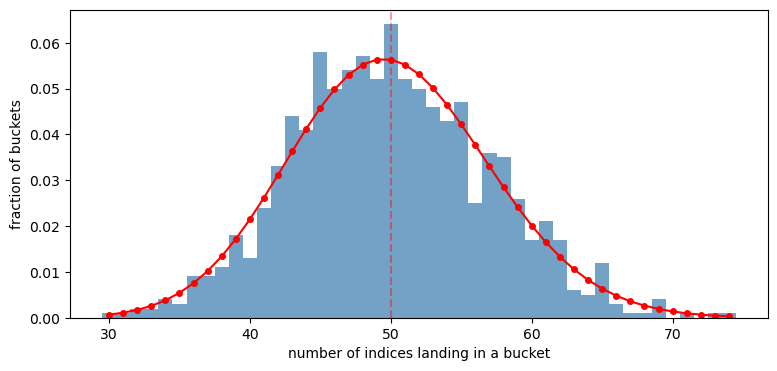

In [10]:
import mmh3
# Let's hash some values, and see how uniformly they distribute into buckets

HASH_BUCKETS = 1000

def bucket_for_index(idx: int) -> int:
    return mmh3.hash(str(idx)) % HASH_BUCKETS # encode ints => bytes for mmh3

N = 50000
sample = np.random.choice(N, size=N, replace=False)
buckets_sample = [bucket_for_index(int(i)) for i in sample]
counts = np.bincount(buckets_sample, minlength=HASH_BUCKETS)

expected_mean = N / HASH_BUCKETS  # = 20 expected indices per bucket

from scipy.stats import poisson as _poisson

x = np.arange(counts.min(), counts.max() + 1)
bins = np.arange(counts.min() - 0.5, counts.max() + 1.5)

plt.figure(figsize=(9, 4))
plt.hist(counts, bins=bins, density=True, color="steelblue", alpha=0.75,
         label="observed fraction of buckets")
plt.plot(x, _poisson.pmf(x, expected_mean), "r-o", markersize=4, linewidth=1.5,
         label=f"{expected_mean:.0f}  ← expected if perfectly uniform")
plt.axvline(expected_mean, color="red", linestyle="--", alpha=0.4)
plt.xlabel("number of indices landing in a bucket")
plt.ylabel("fraction of buckets")
plt.title(f"Distribution of bucket counts: {N} indices → {DEMO_BUCKETS} buckets\n"
          f"(good hash = bars closely follow the Poisson curve)")
plt.legend()
plt.tight_layout()
plt.show()

2. Deterministic: Same input -> same output every time

    This is the property that makes similarity preservation possible. If spectrum A has a peak at bin 12910, and spectrum B also has a peak at bin 12910, both peaks will hash to the *exact same bucket* in both of their vectors. Shared m/z bins -> shared hash buckets -> similar hash vectors. Without this, two identical spectra could produce completely different hash vectors, and clustering would be meaningless.

In [11]:
hashed_string = mmh3.hash("this is the same string".encode())
same_hashed_string = mmh3.hash("this is the same string".encode())

print(hashed_string)
print(same_hashed_string)

assert(hashed_string == same_hashed_string)
print("Both hashes are identical")

-222214556
-222214556
Both hashes are identical


3. Incredibly Fast**: Efficiently computable

    We're hashing every peak in potentially millions of library spectra. A hash function runs in O(1) per element, fast enough that hashing adds negligible overhead compared to the search itself. This keeps the whole OMS preprocessing step tractable.

In [12]:
import timeit


def hash_varied_strings():
    for _ in range(100000):
        hash(f"this is string number {np.random.randint(0, 100000)}")


hash_time_varied = timeit.timeit(hash_varied_strings, number=1)


print(f"Time taken to hash 100,000 different strings: {hash_time_varied} seconds")

Time taken to hash 100,000 different strings: 0.11938737499440322 seconds


### A hash of our own

We'll use `mmh3`, a popular noncryptographic hash function, combined with the modulo operator to map any sparse index to a bucket in the range `[0, 999]`. Let's go back to the example spectrum we have been working with and have already binned.

In [13]:
def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.
    
    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 999)
    """
    # Convert integer to bytes for hashing (mmh3 expects byte input)
    byte_representation = str(num).encode()  # Convert number to string, then to bytes
    
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return mmh3.hash(byte_representation) % HASH_BUCKETS

In [14]:
# @title Example: see how large indices get mapped to small buckets

example_hash_df = (
    annotated_display_df[['Original m/z', 'Ion annotation', 'm/z bin']]
    .copy()
    .rename(columns={'m/z bin': 'Sparse index'})
    .sort_values('Sparse index')
    .head(8)
    .reset_index(drop=True)
)
example_hash_df['Hashed bucket'] = example_hash_df['Sparse index'].apply(hasher)

display(
    example_hash_df.style.format({
        'Original m/z': '{:.4f}',
        'Sparse index': '{:d}',
        'Hashed bucket': '{:d}',
    })
)

print('These are real sparse indices from the example spectrum in Section 2.3.')
print('Each large sparse index is hashed down into one of the 1,000 hash buckets.')

,Original m/z,Ion annotation,Sparse index,Hashed bucket
0,147.1130,y1,3677,67
1,204.1345,y2,5103,88
2,267.1092,b2,6677,840
3,367.1982,y3,9179,433
4,374.1827,y6,9354,480
5,404.1684,b3,10104,196
6,424.2195,y4,10605,826
7,442.7121,y7,11067,620


These are real sparse indices from the example spectrum in Section 2.3.
Each large sparse index is hashed down into one of the 1,000 hash buckets.


#### Handling collisions

What happens when two different m/z bins hash to the same bucket? This is called a **collision**. 

We handle collisions by **adding the intensities together**. As we will see in a minute, this is acceptable because it, on average, happens rarely enough that it preserves similarity between vectors, which is the key idea behind combining clustering and hashing.

In [15]:
# @title Populate our final hash vector with intensities, handling collisions by summation

# Initialize our final hash vector with all zeros
hash_vector = [0] * HASH_BUCKETS 

# Populate the hash buckets with intensities from our sparse map
for sparse_idx, intensity in mz_intensity_map.items():
    # Map the sparse index to a bucket
    bucket_idx = hasher(sparse_idx)
    
    # Add intensity to that bucket (handles collisions by summation)
    hash_vector[bucket_idx] += intensity

In [16]:
# @title Display the hash vector

non_zero_buckets = [(i, val) for i, val in enumerate(hash_vector) if val > 0]

print(f"Hash vector has {len(non_zero_buckets)} non-zero buckets out of {HASH_BUCKETS} total\n")

nonzero_hash_df = pd.DataFrame(non_zero_buckets, columns=['Bucket', 'Intensity'])
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(nonzero_hash_df)

Hash vector has 65 non-zero buckets out of 1000 total



,Bucket,Intensity
0,19,1105.72
1,59,496.66
2,66,570.12
3,67,1312.80
4,68,564.00
...,...,...
60,880,832.34
61,906,741.74
62,907,754.71
63,916,1434.14


#### Step 2 complete!

We now have a fixed-size 1,000-dimensional hash vector, the exact format that clustering algorithms require.

Recall the original goal: speed up OMS by clustering similar spectra so we only compare each query to a small representative subset of the library. Now that every spectrum lives in the same fixed-size vector space, clustering is possible. But there's one thing left to verify: does compressing from 50,000 -> 1,000 dimensions actually preserve which spectra are similar to which? Section 2.6 answers that empirically.

---

## 2.5 Summary of the Spectrum Binning + Feature Hashing Pipeline


| Step | Representation | Size |
|------|----------------|------|
| **Original** | (m/z, intensity) pairs | 24 peaks |
| **Step 1: Binning** | Sparse vector (used dictionary for optimization) | ~50,000 |
| **Step 2: Hashing** | Fixed-size vector | 1,000 dimensions |

The property we need is that spectra that are similar in the original 50,000-dimensional binned space should remain similar after hashing to 1,000 dimensions. If that holds, clustering on hash vectors will correctly group similar spectra,  which is the core idea that makes this approach tractable for OMS.

## 2.6 Verifying that Hashing Preserves Similarity

We claimed that hashing "preserves similarity," that spectra which would cluster together in the original 50,000-dimensional binned space also cluster together in the compressed 1,000-dimensional space. This is the key claim that justifies using hashed vectors for OMS clustering, so let's verify it.

We'll do this in two parts: first define how we actually measure similarity between vectors, then run an empirical check on real spectra.

#### Measuring similarity with cosine similarity

The standard metric for comparing spectral vectors is *cosine similarity*.

It relies on the notion of a *dot product* to measure how similar two vectors are:

$$\vec{x} \cdot \vec{z} > \vec{x} \cdot \vec{y} \implies \vec{x} \text{ is more similar to } \vec{z} \text{ than to } \vec{y}$$

*Cosine similarity* is just a normalized dot product (scaled between 0 and 1).

<details>

<summary><strong>[Optional] Click to see the full cosine similarity formula and an example</strong> </summary>

$$\cos(\theta) = \frac{\vec{x} \cdot \vec{z}}{|\vec{x}| |\vec{z}|}$$

where $\theta$ is the angle between vectors. 

$\cos(\theta = 0) = 1$ => Identical direction

$\cos(\theta = 90) = 0$ => Perpendicular

$\cos(\theta = 180) = -1$ => Opposite direction


**Example:**

$\vec{x} = [0, 500, 0, 1200] \quad \text{(Spectrum A)}$

$\vec{z} = [0, 480, 0, 1190] \quad \text{(Spectrum B - similar)}$

$\vec{y} = [100, 30, 2000, 0] \quad \text{(Spectrum C - different)}$

**Dot products:**

$\vec{x} \cdot \vec{z} = (0)(0) + (500)(480) + (0)(0) + (1200)(1190) = 1,668,000$

$\vec{x} \cdot \vec{y} = (0)(100) + (500)(30) + (0)(2000) + (1200)(0) = 15,000$

Since $1,668,000 \gg 15,000$, spectra A and B would be clustered together, and spectrum C would be separate in this 4-dimensional space.



---
</details>


#### A Short Note on Clustering Algorithms

For demonstration, we can use any clustering algorithm. For this, we've chosen **k-means clustering**, which works as follows:

1. Initialize: Pick *k* random points as initial cluster centers
2. Assign: Assign each spectrum to the nearest center (by cosine similarity)
3. Update: Recompute each center as the mean of all assigned spectra
4. Repeat: Steps 2–3 until assignments stop changing

<br/>
<details><summary><strong>[Optional] Step-by-step k-means on an example (k=2)</strong></summary>

Imagine the pairwise cosine similarity matrix for 4 spectra:

|       | Spec0 | Spec1 | Spec2 | Spec3 |
|:-------:|:-----:|:-----:|:-----:|:-----:|
| Spec0 | 1.0   | 0.8   | 0.3   | 0.6   |
| Spec1 | 0.8   | 1.0   | 0.4   | 0.5   |
| Spec2 | 0.3   | 0.4   | 1.0   | 0.7   |
| Spec3 | 0.6   | 0.5   | 0.7   | 1.0   |

1. Initialize: pick Spec0 and Spec2 as initial centers.

1. Assign
- Spec0: similarity 1.0 to C1(Spec0) vs 0.3 to C2(Spec2) -> C1
- Spec1: similarity 0.8 to C1 vs 0.4 to C2 -> C1
- Spec2: similarity 0.3 to C1 vs 1.0 to C2 -> C2
- Spec3: similarity 0.6 to C1 vs 0.7 to C2 -> C2

Clusters: `C1 = {Spec0, Spec1}`, `C2 = {Spec2, Spec3}`

1. Update: recompute each center as the mean vector of its members.

2. Assign: re-check every spectrum against the updated centers. In this case no spectrum switches clusters -> converged.

Final result: `{Spec0, Spec1}` in one cluster, `{Spec2, Spec3}` in another.

---

</details>

Click play to go through a visual example (no sound), starting from the top.

<video controls>
  <source src="SimilarityPreservationComplete.mp4" type="video/mp4">
</video>


#### Empirical validation

The code below produces two outputs:

1. **Similarity scatter plot**: Each point is one pair of spectra. The x-axis is their cosine similarity in the original sparse-binned space; the y-axis is their cosine similarity in the hashed space. If hashing preserves similarity, all points should hug the diagonal.

2. **Cluster plots**: K-means is run on the shared t-SNE embedding of both representations. The resulting cluster labels are then shown for the unhashed view (left) and the hashed view (right) using the **same colors**. When the cluster shapes match across both panels, it means the same neighborhoods exist in both spaces: hashing has preserved the structure that clustering depends on.

The question we're asking is "if two binned spectra are very similar, are their hashed counterparts also very similar?"

And "if two binned spectra are dissimilar, do their hashed versions reflect that too?" This is the property that lets us trust clustering results on hashed vectors, and ultimately, the property that makes hashing useful for OMS.

> We are comparing binned spectra *to each other*, and hashed spectra *to each other*, not binned to hashed (which would be meaningless, since they have different lengths: ~50,000 vs. 1,000).

> **Note:** Some similarity loss is expected due to hash collisions, but this loss is typically small and acceptable for clustering purposes.

In [17]:
prove_similarity_preservation_plots_and_statistics("Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML", max_spectra=300) 

FileNotFoundError: [Errno 2] No such file or directory: 'Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML'

## 2.7 How does this speed up OMS?

We started this notebook with a problem: OMS is computationally expensive because every experimental spectrum must be compared against every library spectrum, with no precursor mass filter to narrow the search. We introduced clustering as the solution, and spent sections 2.3–2.6 building the machinery to make it work by binning, hashing, and verifying that the hashed representation preserves similarity.

Now let's put it all together and see how clustering on hashed vectors actually reduces the OMS search space.

In fact, let's imagine a fake embedding function:

```python
def embed_spectrum(mz_array: list[float], intensity_array: list[float]) -> list[float]:
    # Step 1: Bin -> Step 2: Hash
    # ...
    return hash_vector  # length 1,000
```


**Phase 1: Build the Library (one-time preprocessing)**

1. For all spectra with **known identity** (from a spectral library), we call this function:

```python
hash_vector_library = embed_spectrum(library_spectrum.mz, library_spectrum.intensity)
```

2. Cluster all library hash vectors (we'll use cosine similarity).


> **Lego analogy:** Sort all your known Lego pieces into piles before you start building.

---

**Phase 2: Identify Unknown Spectra (query phase)**

3. For each unknown **query spectrum**:
```python
hash_vector_query = embed_spectrum(query_spectrum.mz, query_spectrum.intensity)
```

4. Find the nearest cluster representative using cosine similarity.

5. If similarity exceeds a threshold -> assign the query the peptide identity of that cluster.

> **Lego analogy:** When you need a piece, check which pile it belongs to. All pieces in that pile share ~ the same identity.

---

**To Reiterate: Why does this work for modified peptides and OMS as a whole?**

A modified peptide shares MOST of its fragment ions with the unmodified version. The modification only shifts a subset of peaks. Because of this shared structure, the hash vectors remain similar enough that modified and unmodified versions cluster together - enabling identification regardless of PTMs.


---

## 2.8 Worked Example: Spectral Hashing End-to-End

Now let's see the complete pipeline on real data. We'll work with the peptide **AVVQDPALKPLALVYGEATSR**.

Below is its theoretical ion ladder:

In [18]:
make_ion_ladder('AVVQDPALKPLALVYGEATSR')

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,72.04,A,VVQDPALKPLALVYGEATSR,"2,127.18",20
1,2,171.11,AV,VQDPALKPLALVYGEATSR,"2,028.11",19
2,3,270.18,AVV,QDPALKPLALVYGEATSR,"1,929.04",18
3,4,398.24,AVVQ,DPALKPLALVYGEATSR,"1,800.98",17
4,5,513.27,AVVQD,PALKPLALVYGEATSR,"1,685.96",16
5,6,610.32,AVVQDP,ALKPLALVYGEATSR,"1,588.91",15
6,7,681.36,AVVQDPA,LKPLALVYGEATSR,"1,517.87",14
7,8,794.44,AVVQDPAL,KPLALVYGEATSR,"1,404.78",13
8,9,922.54,AVVQDPALK,PLALVYGEATSR,"1,276.69",12
9,10,"1,019.59",AVVQDPALKP,LALVYGEATSR,"1,179.64",11


Let's look at how this ion ladder can be plotted as a "spectrum." The purpose of this is to visualize the spread of m/z values. The intensity values here are meaningless.

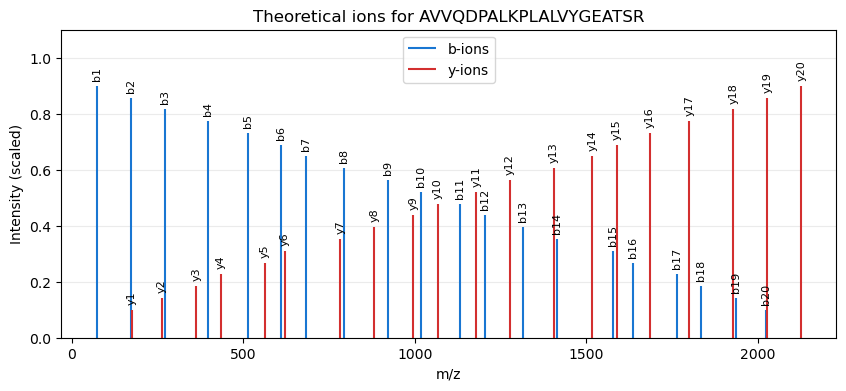

In [19]:
b_mz = [
    72.044114, 171.112528, 270.180942, 398.239520, 513.266463,
    610.319227, 681.356341, 794.440405, 922.535368, 1019.588132,
    1132.672196, 1203.709310, 1316.793374, 1415.861788, 1578.925108,
    1635.946572, 1764.989165, 1836.026279, 1937.073958, 2024.105986
]

y_mz = [
    2127.179698, 2028.111284, 1929.042870, 1800.984292, 1685.957349,
    1588.904585, 1517.867471, 1404.783407, 1276.688444, 1179.635680,
    1066.551616, 995.514502, 882.430438, 783.362024, 620.298704,
    563.277240, 434.234647, 363.197533, 262.149854, 175.117826
]

plot_theoretical_ions(b_mz, y_mz, 'AVVQDPALKPLALVYGEATSR')

Now let's plot a real spectrum and use the theoretical ions above to to annotate it. We'll start with scan 9970, the spectrum of the unmodified AVVQDPALKPLALVYGEATSR peptide.

In [20]:
plot_MS2(get_MS2_object(full_calibrated_mzml_path, 9970, peptide = 'AVVQDPALKPLALVYGEATSR'))

NameError: name 'full_calibrated_mzml_path' is not defined

Although there is inevitable noise that deviates from the theoretical ion ladder, this spectrum overall aligns really well with the ladder. In other words, **a significant proportion of this spectrum's total intensity is accounted for by the theoretical ion ladder.** Let's now look at a modified version of AVVQDPALKPLALVYGEATSR.

In [ ]:

seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 9970, peptide=seq) #AVVQDPALKPLALVYGEATSR
spec_right = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq) #AVVQ[Common Artifact:Deamidation on Q]DPALKPLALVYGEATSR

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 9970 (unmodified peptide)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 9970)")

# Right panel = scan 8090 (modified peptide)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8090)")

fig.suptitle("AVVQDPALKPLALVYGEATSR — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at top
plt.show()

We can repeat that process using an unmodified and modified spectrum from each of the 2 other peptides in our mzml file: IITHPNFNGNTLDNDIMLIK and RMVNNGHSFNVEYDDSQDK.

In [ ]:

seq = 'IITHPNFNGNTLDNDIMLIK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 7567, peptide=seq) #IITHPNFNGNTLDNDIMLIK
spec_right = get_MS2_object(full_calibrated_mzml_path, 8616, peptide=seq) #[Common Artifact:Carbamyl on X]IITHPNFNGNTLDNDIMLIK

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 7567 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 7567)")

# Right panel = scan 8616 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8616)")

fig.suptitle("IITHPNFNGNTLDNDIMLIK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [ ]:

seq = 'RMVNNGHSFNVEYDDSQDK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq) #RMVNNGHSFNVEYDDSQDK
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq) #RMVNN[Common Artifact:Deamidation on N]GHSFNVEYDDSQDK

# Make two panels with shared zxes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 3864 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 3864)")

# Right panel = scan 4022 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 4022)")

fig.suptitle("RMVNNGHSFNVEYDDSQDK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

There are two "trends" you might be noticing by now: <br></br>
1. Generally, when a spectrum (modified or unmodified) is annotated with the theoretical ion ladder for it's associated peptide, there is a significant proportion of that spectrum's intensity that is accounted for by the ion ladder.
2. Unmodified spectra better "match" or are better "accounted for" by the peptide's theoretical ion ladder than modified spectra. But there is not a significant difference.
<br></br>
But what if we were to use the ion ladder of one peptide to annotate the spectrum of a different peptide? Let's try using the theoretical ion ladder of AVVQDPALKPLALVYGEATSR to annotate the spectrum of a modified RMVNNGHSFNVEYDDSQDK peptide. We'll plot that on the right panel. On the left, we'll plot the spectrum of a modified AVVQDPALKPLALVYGEATSR spectrum and annotate it with the AVVQDPALKPLALVYGEATSR ion ladder (just as we did above). In this case, we are plotting spectra from **2 different peptides** and annotating them with **1 ion ladder.**

In [ ]:
seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq)
spec_right = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = modified AVVQDPALKPLALVYGEATSR = scan 8090
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Modified AVVQDPALKPLALVYGEATSR (scan 8090)")

# Right panel = unmodified RMVNNGHSFNVEYDDSQDK = scan 3864
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Unmodified RMVNNGHSFNVEYDDSQDK (Scan 3864)")

fig.suptitle("Annotation by AVVQDPALKPLALVYGEATS's Theoretical Ions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Now we'll annotate the spectrum of the modified RMVNNGHSFNVEYDDSQDK peptide using the theoretical ions of RMVNNGHSFNVEYDDSQDK (on the left) and AVVQDPALKPLALVYGEATSR (on the right).We are plotting **1 spectrum** and annotating it using **2 different theoretical ions from 2 different base peptides.**

In [ ]:
seq_1= 'RMVNNGHSFNVEYDDSQDK'
seq_2 = 'AVVQDPALKPLALVYGEATSR'

spec_left  = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_1)
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_2)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = RMVNNGHSFNVEYDDSQDK Annotation, Scan 4022
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("RMVNNGHSFNVEYDDSQDK Annotation")

# Right panel = AVVQDPALKPLALVYGEATSR Annotation, scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("AVVQDPALKPLALVYGEATSR Annotation")

fig.suptitle("Modified RMVNNGHSFNVEYDDSQDK Spectrum", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Now, you're probably beginning to notice more meaningful trends. In the first example, where we annotated two different spectra (from different peptides) with the same ion ladder, a much greater proportion of the "matching" spectrum's intensity was accounted for by the ion ladder than of the other spectrum's intensity. In the second example, where we annotated the same spectrum using two different ion ladders (one belonging to the same peptide, and one not), a much greater proportion of the spectrum (annotated by it's associated peptide)'s intensity was accounted for by the ion ladder than of the spectrum (annoted by the other peptide)'s intensity. **Let's begin the binning process:**

In [ ]:
# This function should read in an mzml file and return an object of type SpectrumWithTransformations
# Based off of get_MS2_object from Sam Payne lesson 4
def get_SWT_object(
    mzml_path: str,
    scan_number: int,
    full_sequence = None,
) -> "SpectrumWithTransformations":
    
    index = scan_number -1 #scan_number is 1-based, index is 0-based
    with mzml.MzML(mzml_path, use_index=True) as reader: #use_index=True allows us to avoid reading through the entire mzml file
        selected_spectrum = reader.get_by_index(index)
    # Test to see if we accessed the correct scan: PASSED!
    # precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    # print(precursor_mz)
    

    # This finds the cooresponding values in the .mzml file to create our MS2 for a given scan (see the params)
    spectrum_id = selected_spectrum['id']
    retention_time = selected_spectrum['scanList']['scan'][0]['scan start time']
    precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    precursor_charge = int(selected_spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])
    mz_array = np.asarray(selected_spectrum['m/z array'])
    intensity_array = np.asarray(selected_spectrum['intensity array'])
    
    swt_object = SpectrumWithTransformations.SpectrumWithTransformations(
        identifier=spectrum_id,
        scan_number=scan_number,
        precursor_mz=precursor_mz,
        precursor_charge=precursor_charge,
        mz_array=mz_array,
        intensity_array=intensity_array,
        retention_time=retention_time,
        annotation_dictionary=None,
        binned_mz=None,
        hashed_mz=None,
    )

    if full_sequence:
        swt_object = swt_object.annotate_proforma(
            proforma_str = full_sequence,
            fragment_tol_mass = 10, # We consider two peaks (actual and theoretical) "equivalent" if they are within +/- 0.01 Th
            fragment_tol_mode = 'ppm',
            ion_types = 'by',
            max_ion_charge = max(1, precursor_charge - 1)
        )
    return swt_object

In [ ]:
scan_8090 = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)

plot_MS2(scan_8090, title='Scan 8090: Original Spectrum')

In [ ]:
BIN_WIDTH = 0.01
def to_idx(num):
    return int(num // BIN_WIDTH)

# Bin the mz
scan_8090.binned_mz = np.empty_like(scan_8090.mz, dtype=int)
for i in range(len(scan_8090.mz)):
    scan_8090.binned_mz[i] = to_idx(scan_8090.mz[i])

# Create a binned_spectrum SWT object for plotting purposes only
binned_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(binned_spectrum.mz)):
    binned_spectrum.mz[i] = scan_8090.binned_mz[i] #Re-writing the mz_array with the binned mz values

# Plot the binned spectrum
plot_MS2(binned_spectrum, 'Scan 8090: Binned Spectrum')


In [ ]:
def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 999)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % HASH_BUCKETS

# Set-up
hashed_mz = []
hashed_intensity = []
hash_vector = [0] * HASH_BUCKETS
mz_intensity_map = {}
for i, mz in enumerate(scan_8090.mz):
    mz_intensity_map[to_idx(mz)] = scan_8090.intensity[i]

# Hash the mz and add the intensities as we go
for sparse_idx, intensity in mz_intensity_map.items():
    bucket_idx = hasher(sparse_idx)
    hash_vector[bucket_idx] += intensity
    hashed_mz.append(bucket_idx)
    hashed_intensity.append(hash_vector[bucket_idx])

# Update the hashed mz and intensities
scan_8090.hashed_mz = hashed_mz
scan_8090.hashed_intensity = hashed_intensity

# Create a hashed_spectrum SWT object for plotting purposes only
hashed_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR')
for i in range (len(hashed_spectrum.mz)):
    hashed_spectrum.mz[i] = scan_8090.hashed_mz[i] #Re-writing the mz_array with the hashed mz values
    hashed_spectrum.intensity[i] = scan_8090.hashed_intensity[i] #Re-writing the intensity_array with the summed intensity values

# Plot the hashed spectrum
plot_MS2(hashed_spectrum, 'Scan 8090: Hashed Spectrum')

### Side by side
<img src="Scan8090_Original.png" width="400" height="300">
<img src="Scan8090_Binned.png" width="400" height="300">
<img src="Scan8090_Hashed.png" width="400" height="300">

Comparing 146 spectra (out of 146 loaded)
Total unique bins across all spectra: 3340
Computing pairwise similarities...


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




---
### SIMILARITY PRESERVATION METRICS
---
- **Pearson correlation**:  0.9279 (p-value: 0.00e+00)
- **Number of pairwise comparisons**: 10,585
- **Mean absolute error**: 0.0979
---


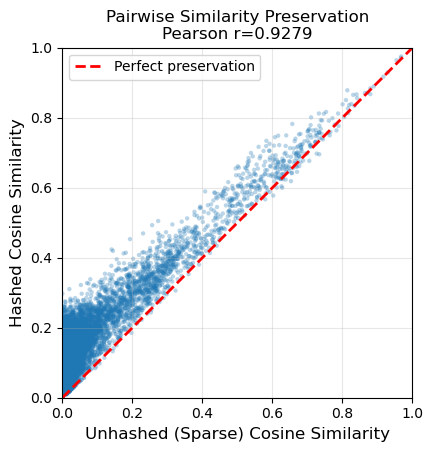

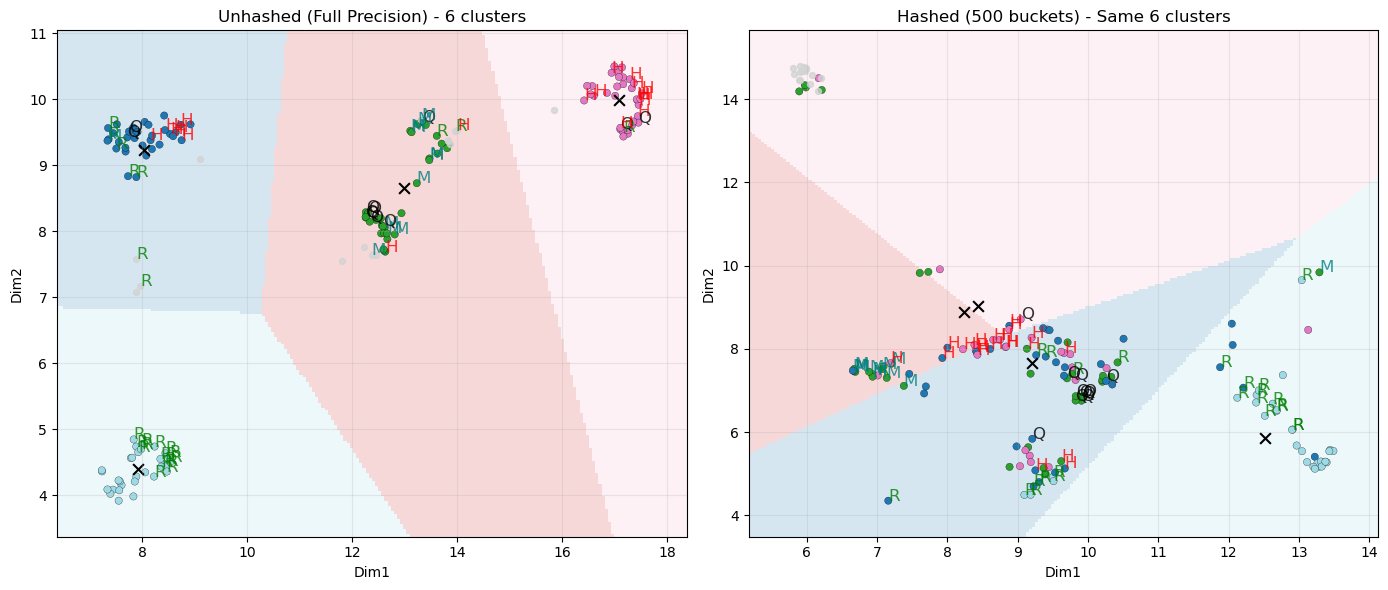

In [4]:
SHHWGYGK_spectra=[
    2921, 2940, 3220, 3246, 3922, 4059, 4091
]

HNGPEHWHKDFPIANGER_Spectra= [
    3770, 3811, 3826, 3960, 3997, 4162, 4165, 4185, 4197, 4494, 
    4507, 4595, 4597, 4643, 4710, 4727, 4949, 4950, 4961, 4963, 5097
]

LVQFHFHWGSSDDQGSEHTVDRK_Spectra = [
    5211, 5225, 5231, 5241, 5248, 5286, 5465, 5996
]

QSPVDIDTK_Spectra = [
    3551, 3819, 4068, 4127, 4293, 4293, 4366, 4477, 
    5155, 5171, 5340, 5480
]

RMVNNGHSFNVEYDDSQDK_Spectra = [
    3325, 3340, 3452, 3483, 3612, 3758, 3809, 3834, 3835, 3837, 
    3864, 3914, 3925, 3982, 3990, 3992, 4010, 4018, 4022, 4023, 
    4086, 4217, 4262, 4510, 4686
]   

MVNNGHSFNVEYDDSQDKAVLK_Spectra = [
    4863, 4711, 4842, 457, 4683, 5124, 4544, 4772,
    5044, 4693, 5356, 6438, 5668, 4690
]

TwoHundred_more = [
    5453, 6968, 7567, 8090, 5358, 5589, 5540, 7141, 7182, 8600, 
    6985, 6497, 7421, 7707, 4863, 9627, 5330, 8601, 9970, 4711, 
    4842, 8616, 7499, 4709, 6435, 5559, 7524, 7414, 7883, 8374, 
    4579, 6673, 4200, 4685, 6636, 7761, 8537, 6175, 8138, 6650, 
    6648, 8085, 6006, 9604, 9823, 6145, 4145, 7940, 6260, 6912, 
    5729, 4016, 3835, 7790, 5577, 5513, 5451, 8666, 7652, 9837, 
    3864, 9853, 9581, 5298, 9263, 7645, 4373, 5543, 3826, 8649, 
    8097, 6510, 4023, 8949, 4597, 5347, 8632, 4683, 8479, 6794, 
    5241, 8634, 8129, 4492, 6441, 3757, 8855, 7708, 8687, 7079, 
    6220, 7538, 6258, 6482, 7961, 8301, 5910, 8536, 5809, 6747, 
    5124, 5574, 5435, 4544, 4022, 7390, 4772, 5499, 3990, 4606, 
    5044, 7046, 3982, 8799, 9318, 4866, 6500, 8854, 4377, 7760, 
    9971, 6258, 5638, 7543, 5856, 7882, 5286, 4829, 8825, 8680, 
    4318, 8651, 6910, 8801, 8620, 8473, 4693, 6983, 8466, 7119, 
    7757, 5356, 4726, 6235, 6433, 4165, 7613, 5430, 4684, 6849, 
    8297, 5604, 6518, 5626, 9506, 6974, 4162, 6863, 7475, 5588, 
    8895, 4953, 7643, 4966, 3979, 3612, 8553, 4510, 7647, 9302, 
    6438, 6128, 4071, 5668, 4690, 5323, 7868, 5786, 8713, 5772, 
    7127, 5132, 6856, 8710, 7684, 7291, 4596, 4706, 6449, 6597, 
    8118, 4153, 8160, 7603, 6475, 9322, 4376, 4192, 3811, 5702
]

# Combines list and removes duplicates
Combined_spectra_list = [
    x for x in set(SHHWGYGK_spectra + HNGPEHWHKDFPIANGER_Spectra + LVQFHFHWGSSDDQGSEHTVDRK_Spectra + QSPVDIDTK_Spectra + RMVNNGHSFNVEYDDSQDK_Spectra + MVNNGHSFNVEYDDSQDKAVLK_Spectra + TwoHundred_more) if 2901 <= x <= 6317
]

prove_similarity_preservation_plots_and_statistics(
    mzml_path=demo_mzml_path,
    hash_buckets=500,
    spectra_idx_to_compare=Combined_spectra_list,
    k_means=6
)